In [17]:
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
import os
from torchvision import transforms
from PIL import Image

In [18]:
transform = transforms.Compose([transforms.ToTensor()])

In [19]:
df = pd.read_csv("D:/New folder/blackhole/test_dataset/labels.csv")

In [20]:
df

,filename,bh_mass_kg,schwarzschild_radius_m,camera_azimuth_rad,camera_elevation_rad,camera_distance_m,disk_r1_m,disk_r2_m,num_extra_bodies
0,bh_000000.png,1.258680e+37,1.869440e+10,0.304192,2.338730,5.192700e+11,5.393470e+10,1.119120e+11,0
1,bh_000001.png,1.454260e+37,2.159910e+10,0.142658,2.318170,5.192700e+11,4.826260e+10,1.284240e+11,0
2,bh_000002.png,1.163100e+37,1.727470e+10,2.705090,0.914031,5.192700e+11,3.979260e+10,1.011450e+11,0
3,bh_000003.png,1.349540e+37,2.004380e+10,0.888671,2.123590,5.192700e+11,4.978000e+10,1.152240e+11,0
4,bh_000004.png,4.573390e+36,6.792540e+09,4.536790,1.271620,5.192700e+11,1.369140e+10,4.038740e+10,0
...,...,...,...,...,...,...,...,...,...
29995,bh_029995.png,1.315750e+37,1.954200e+10,6.183970,2.325990,5.192700e+11,5.601680e+10,8.840090e+10,0
29996,bh_029996.png,7.474720e+36,1.110170e+10,4.937940,1.890340,5.192700e+11,2.653770e+10,6.448470e+10,0
29997,bh_029997.png,5.954910e+36,8.844420e+09,5.943150,1.667010,5.192700e+11,2.158240e+10,4.715020e+10,0
29998,bh_029998.png,1.668440e+37,2.478020e+10,4.482460,2.413810,5.192700e+11,6.939590e+10,1.298670e+11,0


In [21]:
df = df.drop(columns=["num_extra_bodies"])
df

,filename,bh_mass_kg,schwarzschild_radius_m,camera_azimuth_rad,camera_elevation_rad,camera_distance_m,disk_r1_m,disk_r2_m
0,bh_000000.png,1.258680e+37,1.869440e+10,0.304192,2.338730,5.192700e+11,5.393470e+10,1.119120e+11
1,bh_000001.png,1.454260e+37,2.159910e+10,0.142658,2.318170,5.192700e+11,4.826260e+10,1.284240e+11
2,bh_000002.png,1.163100e+37,1.727470e+10,2.705090,0.914031,5.192700e+11,3.979260e+10,1.011450e+11
3,bh_000003.png,1.349540e+37,2.004380e+10,0.888671,2.123590,5.192700e+11,4.978000e+10,1.152240e+11
4,bh_000004.png,4.573390e+36,6.792540e+09,4.536790,1.271620,5.192700e+11,1.369140e+10,4.038740e+10
...,...,...,...,...,...,...,...,...
29995,bh_029995.png,1.315750e+37,1.954200e+10,6.183970,2.325990,5.192700e+11,5.601680e+10,8.840090e+10
29996,bh_029996.png,7.474720e+36,1.110170e+10,4.937940,1.890340,5.192700e+11,2.653770e+10,6.448470e+10
29997,bh_029997.png,5.954910e+36,8.844420e+09,5.943150,1.667010,5.192700e+11,2.158240e+10,4.715020e+10
29998,bh_029998.png,1.668440e+37,2.478020e+10,4.482460,2.413810,5.192700e+11,6.939590e+10,1.298670e+11


In [22]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["filename"]).to_numpy(dtype=np.float32)

scaler = StandardScaler()
X = scaler.fit_transform(X).astype(np.float32)

In [23]:
# X = df.drop(columns=["filename"]).to_numpy(dtype=np.float32)
y = df["filename"].apply(lambda f: os.path.join("D:\\New folder\\blackhole\\test_dataset\\images", os.path.basename(f))).tolist()

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [25]:
class dataset(Dataset):
    def __init__(self, X, y, transform = None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        params = torch.tensor(self.X[index], dtype=torch.float32)
        image = Image.open(self.y[index])
        if self.transform:
            image = self.transform(image)

        return params, image

In [26]:
train_dataset = dataset(X_train, y_train, transform)
test_dataset = dataset(X_test, y_test, transform)

In [27]:
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=True)

In [28]:
class ParamsToImage(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        #Linear layers
        self.fc = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.ReLU(),
            nn.Linear(128, 128 * 5 * 7),   # will reshape to (128, 5, 7)
            nn.ReLU(),
        )
        #Upsampling reverse CNN
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 5x7 -> 10x14
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # 10x14 -> 20x28
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),   # 20x28 -> 40x56
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.ConvTranspose2d(16, 8, kernel_size=4, stride=2, padding=1),    # 40x56 -> 80x112
            nn.BatchNorm2d(8), nn.ReLU(),
            nn.Conv2d(8, 3, kernel_size=3, padding=1),  # 80x112, 3 channels (RGB)
        )

    def forward(self, params):
        x = self.fc(params)
        x = x.view(-1, 128, 5, 7)          # reshape
        x = self.deconv(x)
        x = torch.nn.functional.interpolate(x, size=(150, 200))  # convert to exact target size
        return torch.sigmoid(x)            # squashes output to [0,1] pixel range

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ParamsToImage(n_features=X.shape[1]).to(device)

In [30]:
optimizer = Adam(model.parameters(), lr=2e-4)
loss_fn = nn.L1Loss()

In [31]:
for epoch in range(30):
    model.train()
    total_loss = 0
    for params, images in train_dataloader:
        params, images = params.to(device), images.to(device)
        preds = model(params)
        loss = loss_fn(preds, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}: train loss = {total_loss/len(train_dataloader):.4f}")

Epoch 1: train loss = 0.0821
Epoch 2: train loss = 0.0135
Epoch 3: train loss = 0.0110
Epoch 4: train loss = 0.0098
Epoch 5: train loss = 0.0076
Epoch 6: train loss = 0.0044
Epoch 7: train loss = 0.0040
Epoch 8: train loss = 0.0038
Epoch 9: train loss = 0.0038
Epoch 10: train loss = 0.0037
Epoch 11: train loss = 0.0037
Epoch 12: train loss = 0.0036
Epoch 13: train loss = 0.0036
Epoch 14: train loss = 0.0036
Epoch 15: train loss = 0.0036
Epoch 16: train loss = 0.0036
Epoch 17: train loss = 0.0036
Epoch 18: train loss = 0.0036
Epoch 19: train loss = 0.0036
Epoch 20: train loss = 0.0036
Epoch 21: train loss = 0.0036
Epoch 22: train loss = 0.0036
Epoch 23: train loss = 0.0036
Epoch 24: train loss = 0.0036
Epoch 25: train loss = 0.0035
Epoch 26: train loss = 0.0035
Epoch 27: train loss = 0.0035
Epoch 28: train loss = 0.0035
Epoch 29: train loss = 0.0035
Epoch 30: train loss = 0.0035


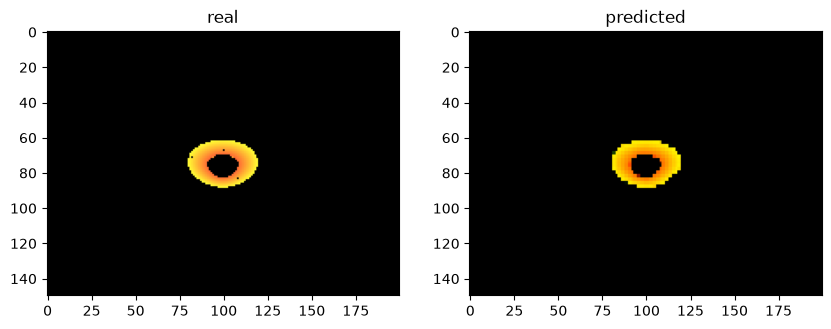

In [87]:
model.eval()
params, real_img = next(iter(test_dataloader))
with torch.no_grad():
    pred_img = model(params.to(device)).cpu()

fig, axs = plt.subplots(1, 2, figsize=(10, 10))
axs[0].imshow(real_img[0].permute(1,2,0)); axs[0].set_title("real")
axs[1].imshow(pred_img[0].permute(1,2,0)); axs[1].set_title("predicted")
plt.show()

In [33]:
torch.save(model.state_dict(), "blackhole_generator.pth")

In [42]:
import joblib

df = pd.read_csv("D:/New folder/blackhole/test_dataset/labels.csv")

df = df.drop(columns=["num_extra_bodies"])

X = df.drop(columns=["filename"]).to_numpy(dtype="float32")

scaler = StandardScaler()
scaler.fit(X)


joblib.dump(scaler, "blackhole_scaler.pkl")

['blackhole_scaler.pkl']